In [37]:
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Load Dataset

In [38]:
df = pd.read_csv("age_gender.csv")
df.head(20)

,age,ethnicity,gender,img_name,pixels
0,1,2,0,20161219203650636.jpg.chip.jpg,129 128 128 126 127 130 133 135 139 142 145 14...
1,1,2,0,20161219222752047.jpg.chip.jpg,164 74 111 168 169 171 175 182 184 188 193 199...
2,1,2,0,20161219222832191.jpg.chip.jpg,67 70 71 70 69 67 70 79 90 103 116 132 145 155...
3,1,2,0,20161220144911423.jpg.chip.jpg,193 197 198 200 199 200 202 203 204 205 208 21...
4,1,2,0,20161220144914327.jpg.chip.jpg,202 205 209 210 209 209 210 211 212 214 218 21...
5,1,2,0,20161220144957407.jpg.chip.jpg,195 198 200 200 198 198 199 199 198 197 197 19...
6,1,2,0,20161220145040127.jpg.chip.jpg,208 216 217 219 222 223 222 221 220 220 221 22...
7,1,2,0,20170109191125532.jpg.chip.jpg,99 142 169 177 179 181 183 186 187 186 191 190...
8,1,2,0,20161219222749039.jpg.chip.jpg,127 127 133 140 143 148 152 157 160 165 172 17...
9,1,2,0,20170109191209991.jpg.chip.jpg,199 211 211 214 216 216 219 221 222 224 219 21...


In [39]:
df['pixels'] = df['pixels'].apply(
    lambda x: np.fromstring(x, dtype=np.uint8, sep=' ').reshape(48, 48)
)
    

In [40]:
df.dtypes

age           int64
ethnicity     int64
gender        int64
img_name        str
pixels       object
dtype: object

In [ ]:
df.drop('img_name', axis=1, inplace=True)

ValueError: No axis named 3 for object type DataFrame

In [43]:
df.head()

,age,ethnicity,gender,pixels
0,1,2,0,"[[129, 128, 128, 126, 127, 130, 133, 135, 139,..."
1,1,2,0,"[[164, 74, 111, 168, 169, 171, 175, 182, 184, ..."
2,1,2,0,"[[67, 70, 71, 70, 69, 67, 70, 79, 90, 103, 116..."
3,1,2,0,"[[193, 197, 198, 200, 199, 200, 202, 203, 204,..."
4,1,2,0,"[[202, 205, 209, 210, 209, 209, 210, 211, 212,..."


In [83]:
x = np.array(df["pixels"].tolist(), dtype=np.float32)
y = df["ethnicity"]

In [84]:
from sklearn.model_selection import train_test_split

In [85]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [87]:
from tensorflow.keras import models, layers, regularizers

model = models.Sequential()

# Block 1
model.add(layers.Conv2D(32, (3,3), activation='relu',
                        kernel_regularizer=regularizers.l2(0.0001),
                        input_shape=(48,48,1)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Dropout(0.2))

# Block 2
model.add(layers.Conv2D(64, (3,3), activation='relu',
                        kernel_regularizer=regularizers.l2(0.0001)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Dropout(0.2))

# Block 3
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Dropout(0.2))

# GAP instead of Flatten
model.add(layers.GlobalAveragePooling2D())

# Dense
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.3))

# Output
model.add(layers.Dense(len(set(y)), activation='softmax'))

In [88]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 21, 21, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,877 (499.52 KB)

 Trainable params: 127,429 (497.77 KB)

 Non-trainable params: 448 (1.75 KB)

In [89]:
from tensorflow.keras.callbacks import EarlyStopping

In [90]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

In [91]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    epochs=70,
    validation_data=(x_test, y_test),
    callbacks=[early_stop],
    batch_size=32
)

Epoch 1/70
593/593 ━━━━━━━━━━━━━━━━━━━━ 25s 39ms/step - accuracy: 0.5330 - loss: 1.2271 - val_accuracy: 0.5630 - val_loss: 1.2939
Epoch 2/70
593/593 ━━━━━━━━━━━━━━━━━━━━ 42s 41ms/step - accuracy: 0.6503 - loss: 0.9658 - val_accuracy: 0.6754 - val_loss: 0.8928
Epoch 3/70
593/593 ━━━━━━━━━━━━━━━━━━━━ 25s 42ms/step - accuracy: 0.6864 - loss: 0.8758 - val_accuracy: 0.6172 - val_loss: 1.1758
Epoch 4/70
593/593 ━━━━━━━━━━━━━━━━━━━━ 25s 42ms/step - accuracy: 0.7042 - loss: 0.8288 - val_accuracy: 0.7032 - val_loss: 0.8148
Epoch 5/70
593/593 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.7174 - loss: 0.8003 - val_accuracy: 0.7072 - val_loss: 0.8339
Epoch 6/70
593/593 ━━━━━━━━━━━━━━━━━━━━ 29s 50ms/step - accuracy: 0.7290 - loss: 0.7667 - val_accuracy: 0.7045 - val_loss: 0.9093
Epoch 7/70
593/593 ━━━━━━━━━━━━━━━━━━━━ 27s 46ms/step - accuracy: 0.7351 - loss: 0.7466 - val_accuracy: 0.7220 - val_loss: 0.8245
Epoch 8/70
593/593 ━━━━━━━━━━━━━━━━━━━━ 27s 45ms/step - accuracy: 0.7439 - loss: 0.7203 - 

149/149 - 1s - 7ms/step - accuracy: 0.7811 - loss: 0.6287


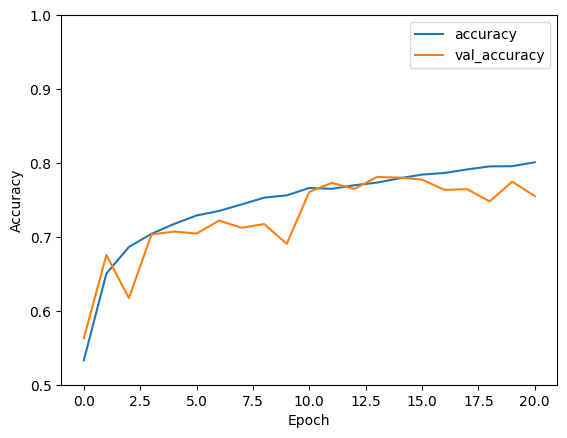

In [92]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend()

test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)

In [123]:
y_test.value_counts()

ethnicity
0    2047
1     904
3     804
2     657
4     329
Name: count, dtype: int64

In [126]:
df.columns

Index(['age', 'ethnicity', 'gender', 'pixels'], dtype='str')

In [130]:
q = df[df['ethnicity'] == 2]
q.head()

,age,ethnicity,gender,pixels
0,1,2,0,"[[129, 128, 128, 126, 127, 130, 133, 135, 139,..."
1,1,2,0,"[[164, 74, 111, 168, 169, 171, 175, 182, 184, ..."
2,1,2,0,"[[67, 70, 71, 70, 69, 67, 70, 79, 90, 103, 116..."
3,1,2,0,"[[193, 197, 198, 200, 199, 200, 202, 203, 204,..."
4,1,2,0,"[[202, 205, 209, 210, 209, 209, 210, 211, 212,..."


In [ ]:
ethnicity = ["White", "Black", "Asian", "Indian", "Others"]

In [135]:
import cv2
img_path = "images/img1069.png"

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (48, 48))

img = img.reshape(1, 48, 48, 1)
img = img.astype("float32")

ans = model.predict(img)
predicted_class = np.argmax(ans)
print(ethnicity[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
White


In [136]:
model.save("ethnicity.h5")